In [3]:
import numpy as np

**Module** is an abstract class which defines fundamental methods necessary for a training a neural network. You do not need to change anything here, just read the comments.

In [4]:
class Module(object):
    """
    Basically, you can think of a module as of a something (black box)
    which can process `input` data and produce `ouput` data.
    This is like applying a function which is called `forward`:

        output = module.forward(input)

    The module should be able to perform a backward pass: to differentiate the `forward` function.
    More, it should be able to differentiate it if is a part of chain (chain rule).
    The latter implies there is a gradient from previous step of a chain rule.

        gradInput = module.backward(input, gradOutput)
    """
    def __init__ (self):
        self.output = None
        self.gradInput = None
        self.training = True

    def forward(self, input):
        """
        Takes an input object, and computes the corresponding output of the module.
        """
        return self.updateOutput(input)

    def backward(self,input, gradOutput):
        """
        Performs a backpropagation step through the module, with respect to the given input.

        This includes
         - computing a gradient w.r.t. `input` (is needed for further backprop),
         - computing a gradient w.r.t. parameters (to update parameters while optimizing).
        """
        self.updateGradInput(input, gradOutput)
        self.accGradParameters(input, gradOutput)
        return self.gradInput


    def updateOutput(self, input):
        """
        Computes the output using the current parameter set of the class and input.
        This function returns the result which is stored in the `output` field.

        Make sure to both store the data in `output` field and return it.
        """

        # The easiest case:

        # self.output = input
        # return self.output

        pass

    def updateGradInput(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own input.
        This is returned in `gradInput`. Also, the `gradInput` state variable is updated accordingly.

        The shape of `gradInput` is always the same as the shape of `input`.

        Make sure to both store the gradients in `gradInput` field and return it.
        """

        # The easiest case:

        # self.gradInput = gradOutput
        # return self.gradInput

        pass

    def accGradParameters(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own parameters.
        No need to override if module has no parameters (e.g. ReLU).
        """
        pass

    def zeroGradParameters(self):
        """
        Zeroes `gradParams` variable if the module has params.
        """
        pass

    def getParameters(self):
        """
        Returns a list with its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def getGradParameters(self):
        """
        Returns a list with gradients with respect to its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def train(self):
        """
        Sets training mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = True

    def evaluate(self):
        """
        Sets evaluation mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = False

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Module"

# Sequential container

**Define** a forward and backward pass procedures.

In [5]:
class Sequential(Module):
    """
         This class implements a container, which processes `input` data sequentially.

         `input` is processed by each module (layer) in self.modules consecutively.
         The resulting array is called `output`.
    """

    def __init__(self):
        super(Sequential, self).__init__()
        self.modules = []

    def add(self, module):
        self.modules.append(module)

    def updateOutput(self, input):
        current_input = input
        for module in self.modules:
            current_input = module.forward(current_input)
        self.output = current_input
        return self.output

    def backward(self, input, gradOutput):
        current_grad = gradOutput

        for i in range(len(self.modules) - 1, -1, -1):
            if i == 0:
                module_input = input
            else:
                module_input = self.modules[i - 1].output

            current_grad = self.modules[i].backward(module_input, current_grad)

        self.gradInput = current_grad
        return self.gradInput

    def zeroGradParameters(self):
        for module in self.modules:
            module.zeroGradParameters()

    def getParameters(self):
        return [x.getParameters() for x in self.modules]

    def getGradParameters(self):
        return [x.getGradParameters() for x in self.modules]

    def __repr__(self):
        string = "".join([str(x) + '\n' for x in self.modules])
        return string

    def __getitem__(self, x):
        return self.modules.__getitem__(x)

    def train(self):
        self.training = True
        for module in self.modules:
            module.train()

    def evaluate(self):
        self.training = False
        for module in self.modules:
            module.evaluate()

# Layers

## 1 (0.2). Linear transform layer
Also known as dense layer, fully-connected layer, FC-layer, InnerProductLayer (in caffe), affine transform
- input:   **`batch_size x n_feats1`**
- output: **`batch_size x n_feats2`**

In [6]:
class Linear(Module):
    """
    A module which applies a linear transformation
    A common name is fully-connected layer, InnerProductLayer in caffe.

    The module should work with 2D input of shape (n_samples, n_feature).
    """
    def __init__(self, n_in, n_out):
        super(Linear, self).__init__()

        stdv = 1./np.sqrt(n_in)
        self.W = np.random.uniform(-stdv, stdv, size = (n_out, n_in))
        self.b = np.random.uniform(-stdv, stdv, size = n_out)

        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)

    def updateOutput(self, input):
        self.output = input.dot(self.W.T) + self.b
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput.dot(self.W)
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradW += gradOutput.T.dot(input)
        self.gradb += np.sum(gradOutput, axis=0)

    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

    def __repr__(self):
        s = self.W.shape
        q = 'Linear %d -> %d' %(s[1],s[0])
        return q

## 2. (0.2) SoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{softmax}(x)_i = \frac{\exp x_i} {\sum_j \exp x_j}$

Recall that $\text{softmax}(x) == \text{softmax}(x - \text{const})$. It makes possible to avoid computing exp() from large argument.

In [7]:
class SoftMax(Module):
    def __init__(self):
         super(SoftMax, self).__init__()

    def updateOutput(self, input):
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))
        self.output = np.exp(self.output)
        self.output /= np.sum(self.output, axis=1, keepdims=True)
        return self.output

    def updateGradInput(self, input, gradOutput):
        tmp = np.sum(gradOutput * self.output, axis=1, keepdims=True)
        self.gradInput = self.output * (gradOutput - tmp)
        return self.gradInput

    def __repr__(self):
        return "SoftMax"

## 3. (0.2) LogSoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{logsoftmax}(x)_i = \log\text{softmax}(x)_i = x_i - \log {\sum_j \exp x_j}$

The main goal of this layer is to be used in computation of log-likelihood loss.

In [8]:
class LogSoftMax(Module):
    def __init__(self):
         super(LogSoftMax, self).__init__()

    def updateOutput(self, input):
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))
        log_sum_exp = np.log(np.sum(np.exp(self.output), axis=1, keepdims=True))
        self.output = self.output - log_sum_exp
        return self.output

    def updateGradInput(self, input, gradOutput):
        softmax = np.exp(self.output)
        sum_grad = np.sum(gradOutput, axis=1, keepdims=True)
        self.gradInput = gradOutput - softmax * sum_grad
        return self.gradInput

    def __repr__(self):
        return "LogSoftMax"

## 4. (0.3) Batch normalization
One of the most significant recent ideas that impacted NNs a lot is [**Batch normalization**](http://arxiv.org/abs/1502.03167). The idea is simple, yet effective: the features should be whitened ($mean = 0$, $std = 1$) all the way through NN. This improves the convergence for deep models letting it train them for days but not weeks. **You are** to implement the first part of the layer: features normalization. The second part (`ChannelwiseScaling` layer) is implemented below.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

The layer should work as follows. While training (`self.training == True`) it transforms input as $$y = \frac{x - \mu}  {\sqrt{\sigma + \epsilon}}$$
where $\mu$ and $\sigma$ - mean and variance of feature values in **batch** and $\epsilon$ is just a small number for numericall stability. Also during training, layer should maintain exponential moving average values for mean and variance:
```
    self.moving_mean = self.moving_mean * alpha + batch_mean * (1 - alpha)
    self.moving_variance = self.moving_variance * alpha + batch_variance * (1 - alpha)
```
During testing (`self.training == False`) the layer normalizes input using moving_mean and moving_variance.

Note that decomposition of batch normalization on normalization itself and channelwise scaling here is just a common **implementation** choice. In general "batch normalization" always assumes normalization + scaling.

In [9]:
class BatchNormalization(Module):
    EPS = 1e-5

    def __init__(self, alpha=0.):
        super(BatchNormalization, self).__init__()
        self.alpha = alpha

        self.moving_mean = None
        self.moving_variance = None
        self.input_shape = None

        self.x_hat = None
        self.std_inv = None
        self.batch_mean = None
        self.batch_var = None

    def _reshape_input(self, input):
        self.input_shape = input.shape
        if len(input.shape) == 2:
            return input
        elif len(input.shape) == 4:
            N, C, H, W = input.shape
            return input.transpose(0, 2, 3, 1).reshape(-1, C)
        else:
            raise ValueError("BatchNormalization supports only 2D or 4D input")

    def _reshape_output(self, output):
        if len(self.input_shape) == 2:
            return output
        elif len(self.input_shape) == 4:
            N, C, H, W = self.input_shape
            return output.reshape(N, H, W, C).transpose(0, 3, 1, 2)
        else:
            raise ValueError("BatchNormalization supports only 2D or 4D input")

    def updateOutput(self, input):
        x = self._reshape_input(input).astype(np.float64)
        n_features = x.shape[1]

        if self.moving_mean is None:
            self.moving_mean = np.zeros(n_features, dtype=np.float64)
            self.moving_variance = np.ones(n_features, dtype=np.float64)

        if self.training:
            self.batch_mean = np.mean(x, axis=0)
            self.batch_var = np.var(x, axis=0, ddof=0)

            self.std_inv = 1.0 / np.sqrt(self.batch_var + self.EPS)
            self.x_hat = (x - self.batch_mean) * self.std_inv

            self.moving_mean = self.alpha * self.moving_mean + (1.0 - self.alpha) * self.batch_mean

            n = x.shape[0]
            unbiased_var = self.batch_var * n / (n - 1) if n > 1 else self.batch_var
            self.moving_variance = self.alpha * self.moving_variance + (1.0 - self.alpha) * unbiased_var

            out = self.x_hat
        else:
            out = (x - self.moving_mean) / np.sqrt(self.moving_variance + self.EPS)

        self.output = self._reshape_output(out.astype(np.float32))
        return self.output

    def updateGradInput(self, input, gradOutput):
        dout = self._reshape_input(gradOutput).astype(np.float64)

        if self.training:
            N = dout.shape[0]

            sum_dout = np.sum(dout, axis=0)
            sum_dout_xhat = np.sum(dout * self.x_hat, axis=0)

            dx = (1.0 / N) * self.std_inv * (
                N * dout - sum_dout - self.x_hat * sum_dout_xhat
            )
        else:
            dx = dout / np.sqrt(self.moving_variance + self.EPS)

        self.gradInput = self._reshape_output(dx.astype(np.float32))
        return self.gradInput

    def __repr__(self):
        return "BatchNormalization"

In [10]:
class ChannelwiseScaling(Module):
    r"""
       Implements linear transform of input y = \gamma * x + \beta
       where \gamma, \beta - learnable vectors of length x.shape[-1]
    """
    def __init__(self, n_out):
        super(ChannelwiseScaling, self).__init__()

        stdv = 1./np.sqrt(n_out)
        self.gamma = np.random.uniform(-stdv, stdv, size=n_out)
        self.beta = np.random.uniform(-stdv, stdv, size=n_out)

        self.gradGamma = np.zeros_like(self.gamma)
        self.gradBeta = np.zeros_like(self.beta)

    def updateOutput(self, input):
        self.output = input * self.gamma + self.beta
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * self.gamma
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradBeta += np.sum(gradOutput, axis=0)
        self.gradGamma += np.sum(gradOutput * input, axis=0)

    def zeroGradParameters(self):
        self.gradGamma.fill(0)
        self.gradBeta.fill(0)

    def getParameters(self):
        return [self.gamma, self.beta]

    def getGradParameters(self):
        return [self.gradGamma, self.gradBeta]

    def __repr__(self):
        return "ChannelwiseScaling"

Practical notes. If BatchNormalization is placed after a linear transformation layer (including dense layer, convolutions, channelwise scaling) that implements function like `y = weight * x + bias`, than bias adding become useless and could be omitted since its effect will be discarded while batch mean subtraction. If BatchNormalization (followed by `ChannelwiseScaling`) is placed before a layer that propagates scale (including ReLU, LeakyReLU) followed by any linear transformation layer than parameter `gamma` in `ChannelwiseScaling` could be freezed since it could be absorbed into the linear transformation layer.

## 5. (0.3) Dropout
Implement [**dropout**](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf). The idea and implementation is really simple: just multimply the input by $Bernoulli(p)$ mask. Here $p$ is probability of an element to be zeroed.

This has proven to be an effective technique for regularization and preventing the co-adaptation of neurons.

While training (`self.training == True`) it should sample a mask on each iteration (for every batch), zero out elements and multiply elements by $1 / (1 - p)$. The latter is needed for keeping mean values of features close to mean values which will be in test mode. When testing this module should implement identity transform i.e. `self.output = input`.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

In [11]:
class Dropout(Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()

        self.p = p
        self.mask = None

    def updateOutput(self, input):
        if self.training:
            self.mask = (np.random.rand(*input.shape) >= self.p) / (1 - self.p)
            self.output = input * self.mask
        else:
            self.output = input
        return self.output

    def updateGradInput(self, input, gradOutput):
        if self.training:
            self.gradInput = gradOutput * self.mask
        else:
            self.gradInput = gradOutput
        return self.gradInput

    def __repr__(self):
        return "Dropout"

#6. (2.0) Conv2d
Implement [**Conv2d**](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). Use only this list of parameters: (in_channels, out_channels, kernel_size, stride, padding, bias, padding_mode) and fix dilation=1 and groups=1.

In [12]:
class Conv2d(Module):
    def __init__(self, in_channels, out_channels, kernel_size,
                 stride=1, padding='valid', bias=True, padding_mode='zeros'):
        super(Conv2d, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.stride = stride if isinstance(stride, tuple) else (stride, stride)
        self.padding = padding
        self.use_bias = bias
        self.padding_mode = padding_mode

        if self.padding not in ['same', 'valid']:
            raise ValueError("Only padding='same' and padding='valid' are supported")

        if self.padding_mode != 'zeros':
            raise ValueError("Only padding_mode='zeros' is supported")

        kh, kw = self.kernel_size
        stdv = 1. / np.sqrt(in_channels * kh * kw)

        self.weight = np.random.uniform(-stdv, stdv, size=(out_channels, in_channels, kh, kw))
        self.gradWeight = np.zeros_like(self.weight)

        if self.use_bias:
            self.bias = np.random.uniform(-stdv, stdv, size=(out_channels,))
            self.gradBias = np.zeros_like(self.bias)
        else:
            self.bias = None
            self.gradBias = None

        self._last_padding = None

    def _pad_input(self, input):
        _, _, H, W = input.shape
        kh, kw = self.kernel_size
        sh, sw = self.stride

        if self.padding == 'valid':
            pad_top = pad_bottom = pad_left = pad_right = 0
        else:  # padding == 'same'
            out_h = int(np.ceil(H / sh))
            out_w = int(np.ceil(W / sw))

            pad_h = max((out_h - 1) * sh + kh - H, 0)
            pad_w = max((out_w - 1) * sw + kw - W, 0)

            pad_top = pad_h // 2
            pad_bottom = pad_h - pad_top
            pad_left = pad_w // 2
            pad_right = pad_w - pad_left

        self._last_padding = (pad_top, pad_bottom, pad_left, pad_right)

        if pad_top == 0 and pad_bottom == 0 and pad_left == 0 and pad_right == 0:
            return input

        return np.pad(
            input,
            ((0, 0), (0, 0), (pad_top, pad_bottom), (pad_left, pad_right)),
            mode='constant',
            constant_values=0
        )

    def updateOutput(self, input):
        batch_size, _, _, _ = input.shape
        out_channels, _, kh, kw = self.weight.shape
        sh, sw = self.stride

        input_padded = self._pad_input(input)
        H_padded, W_padded = input_padded.shape[2], input_padded.shape[3]

        H_out = (H_padded - kh) // sh + 1
        W_out = (W_padded - kw) // sw + 1

        self.output = np.zeros((batch_size, out_channels, H_out, W_out), dtype=input.dtype)

        for n in range(batch_size):
            for oc in range(out_channels):
                for i in range(H_out):
                    for j in range(W_out):
                        h_start = i * sh
                        w_start = j * sw
                        h_end = h_start + kh
                        w_end = w_start + kw

                        patch = input_padded[n, :, h_start:h_end, w_start:w_end]
                        self.output[n, oc, i, j] = np.sum(patch * self.weight[oc])

                        if self.use_bias:
                            self.output[n, oc, i, j] += self.bias[oc]

        return self.output

    def updateGradInput(self, input, gradOutput):
        batch_size, _, H, W = input.shape
        out_channels, _, kh, kw = self.weight.shape
        sh, sw = self.stride

        input_padded = self._pad_input(input)
        gradInput_padded = np.zeros_like(input_padded)

        H_out, W_out = gradOutput.shape[2], gradOutput.shape[3]

        for n in range(batch_size):
            for oc in range(out_channels):
                for i in range(H_out):
                    for j in range(W_out):
                        h_start = i * sh
                        w_start = j * sw
                        h_end = h_start + kh
                        w_end = w_start + kw

                        gradInput_padded[n, :, h_start:h_end, w_start:w_end] += (
                            gradOutput[n, oc, i, j] * self.weight[oc]
                        )

        pad_top, pad_bottom, pad_left, pad_right = self._last_padding
        self.gradInput = gradInput_padded[:, :, pad_top:pad_top + H, pad_left:pad_left + W]
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        batch_size = input.shape[0]
        out_channels, _, kh, kw = self.weight.shape
        sh, sw = self.stride

        input_padded = self._pad_input(input)
        H_out, W_out = gradOutput.shape[2], gradOutput.shape[3]

        for n in range(batch_size):
            for oc in range(out_channels):
                for i in range(H_out):
                    for j in range(W_out):
                        h_start = i * sh
                        w_start = j * sw
                        h_end = h_start + kh
                        w_end = w_start + kw

                        patch = input_padded[n, :, h_start:h_end, w_start:w_end]
                        self.gradWeight[oc] += gradOutput[n, oc, i, j] * patch

                        if self.use_bias:
                            self.gradBias[oc] += gradOutput[n, oc, i, j]

    def zeroGradParameters(self):
        self.gradWeight.fill(0)
        if self.use_bias:
            self.gradBias.fill(0)

    def getParameters(self):
        if self.use_bias:
            return [self.weight, self.bias]
        return [self.weight]

    def getGradParameters(self):
        if self.use_bias:
            return [self.gradWeight, self.gradBias]
        return [self.gradWeight]

    def __repr__(self):
        return "Conv2d"

#7. (0.5) Implement [**MaxPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) and [**AvgPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html). Use only parameters like kernel_size, stride, padding (negative infinity for maxpool and zero for avgpool) and other parameters fixed as in framework.

In [13]:
class MaxPool2d(Module):
    def __init__(self, kernel_size, stride, padding):
        super(MaxPool2d, self).__init__()

        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.stride = stride if isinstance(stride, tuple) else (stride, stride)
        self.padding = padding if isinstance(padding, tuple) else (padding, padding)

        self.max_indices = None

    def updateOutput(self, input):
        N, C, H, W = input.shape
        kh, kw = self.kernel_size
        sh, sw = self.stride
        ph, pw = self.padding

        input_padded = np.pad(
            input,
            ((0, 0), (0, 0), (ph, ph), (pw, pw)),
            mode='constant',
            constant_values=-np.inf
        )

        H_out = (H + 2 * ph - kh) // sh + 1
        W_out = (W + 2 * pw - kw) // sw + 1

        self.output = np.zeros((N, C, H_out, W_out))
        self.max_indices = np.zeros((N, C, H_out, W_out, 2), dtype=int)

        for n in range(N):
            for c in range(C):
                for i in range(H_out):
                    for j in range(W_out):
                        h_start = i * sh
                        w_start = j * sw
                        h_end = h_start + kh
                        w_end = w_start + kw

                        window = input_padded[n, c, h_start:h_end, w_start:w_end]
                        max_idx = np.unravel_index(np.argmax(window), window.shape)

                        self.output[n, c, i, j] = window[max_idx]
                        self.max_indices[n, c, i, j] = (h_start + max_idx[0], w_start + max_idx[1])

        return self.output

    def updateGradInput(self, input, gradOutput):
        N, C, H, W = input.shape
        ph, pw = self.padding

        gradInput_padded = np.zeros((N, C, H + 2 * ph, W + 2 * pw))

        H_out, W_out = gradOutput.shape[2], gradOutput.shape[3]

        for n in range(N):
            for c in range(C):
                for i in range(H_out):
                    for j in range(W_out):
                        h_idx, w_idx = self.max_indices[n, c, i, j]
                        gradInput_padded[n, c, h_idx, w_idx] += gradOutput[n, c, i, j]

        if ph == 0 and pw == 0:
            self.gradInput = gradInput_padded
        else:
            self.gradInput = gradInput_padded[:, :, ph:ph + H, pw:pw + W]

        return self.gradInput

    def __repr__(self):
        return "MaxPool2d"

class AvgPool2d(Module):
    def __init__(self, kernel_size, stride, padding):
        super(AvgPool2d, self).__init__()

        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.stride = stride if isinstance(stride, tuple) else (stride, stride)
        self.padding = padding if isinstance(padding, tuple) else (padding, padding)

    def updateOutput(self, input):
        N, C, H, W = input.shape
        kh, kw = self.kernel_size
        sh, sw = self.stride
        ph, pw = self.padding

        input_padded = np.pad(
            input,
            ((0, 0), (0, 0), (ph, ph), (pw, pw)),
            mode='constant',
            constant_values=0
        )

        H_out = (H + 2 * ph - kh) // sh + 1
        W_out = (W + 2 * pw - kw) // sw + 1

        self.output = np.zeros((N, C, H_out, W_out))

        for n in range(N):
            for c in range(C):
                for i in range(H_out):
                    for j in range(W_out):
                        h_start = i * sh
                        w_start = j * sw
                        h_end = h_start + kh
                        w_end = w_start + kw

                        window = input_padded[n, c, h_start:h_end, w_start:w_end]
                        self.output[n, c, i, j] = np.mean(window)

        return self.output

    def updateGradInput(self, input, gradOutput):
        N, C, H, W = input.shape
        kh, kw = self.kernel_size
        sh, sw = self.stride
        ph, pw = self.padding

        gradInput_padded = np.zeros((N, C, H + 2 * ph, W + 2 * pw))

        H_out, W_out = gradOutput.shape[2], gradOutput.shape[3]
        scale = kh * kw

        for n in range(N):
            for c in range(C):
                for i in range(H_out):
                    for j in range(W_out):
                        h_start = i * sh
                        w_start = j * sw
                        h_end = h_start + kh
                        w_end = w_start + kw

                        gradInput_padded[n, c, h_start:h_end, w_start:w_end] += gradOutput[n, c, i, j] / scale

        if ph == 0 and pw == 0:
            self.gradInput = gradInput_padded
        else:
            self.gradInput = gradInput_padded[:, :, ph:ph + H, pw:pw + W]

        return self.gradInput

    def __repr__(self):
        return "AvgPool2d"

#8. (0.3) Implement **GlobalMaxPool2d** and **GlobalAvgPool2d**. They do not have testing and parameters are up to you but they must aggregate information within channels. Write test functions for these layers on your own.

In [14]:
class GlobalMaxPool2d(Module):
    def __init__(self):
        super(GlobalMaxPool2d, self).__init__()
        self.max_indices = None
        self.input_shape = None

    def updateOutput(self, input):
        self.input_shape = input.shape
        N, C, H, W = input.shape

        self.output = np.max(input, axis=(2, 3))
        self.max_indices = np.zeros((N, C, 2), dtype=int)

        for n in range(N):
            for c in range(C):
                idx = np.unravel_index(np.argmax(input[n, c]), (H, W))
                self.max_indices[n, c] = idx

        return self.output

    def updateGradInput(self, input, gradOutput):
        N, C, H, W = self.input_shape
        self.gradInput = np.zeros((N, C, H, W))

        for n in range(N):
            for c in range(C):
                h, w = self.max_indices[n, c]
                self.gradInput[n, c, h, w] = gradOutput[n, c]

        return self.gradInput

    def __repr__(self):
        return "GlobalMaxPool2d"
    
    
    
class GlobalAvgPool2d(Module):
    def __init__(self):
        super(GlobalAvgPool2d, self).__init__()
        self.input_shape = None

    def updateOutput(self, input):
        self.input_shape = input.shape
        self.output = np.mean(input, axis=(2, 3))
        return self.output

    def updateGradInput(self, input, gradOutput):
        N, C, H, W = self.input_shape
        self.gradInput = np.zeros((N, C, H, W))

        for n in range(N):
            for c in range(C):
                self.gradInput[n, c, :, :] = gradOutput[n, c] / (H * W)

        return self.gradInput

    def __repr__(self):
        return "GlobalAvgPool2d"

#9. (0.2) Implement [**Flatten**](https://pytorch.org/docs/stable/generated/torch.flatten.html)

In [15]:
class Flatten(Module):
    def __init__(self, start_dim=0, end_dim=-1):
        super(Flatten, self).__init__()

        self.start_dim = start_dim
        self.end_dim = end_dim

    def updateOutput(self, input):
        shape = input.shape
        ndim = len(shape)

        start_dim = self.start_dim if self.start_dim >= 0 else self.start_dim + ndim
        end_dim = self.end_dim if self.end_dim >= 0 else self.end_dim + ndim

        flattened_dim = np.prod(shape[start_dim:end_dim + 1])

        new_shape = (
            shape[:start_dim] +
            (flattened_dim,) +
            shape[end_dim + 1:]
        )

        self.output = input.reshape(new_shape)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput.reshape(input.shape)
        return self.gradInput

    def __repr__(self):
        return "Flatten"

# Activation functions

Here's the complete example for the **Rectified Linear Unit** non-linearity (aka **ReLU**):

In [16]:
class ReLU(Module):
    def __init__(self):
         super(ReLU, self).__init__()

    def updateOutput(self, input):
        self.output = np.maximum(input, 0)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = np.multiply(gradOutput , input > 0)
        return self.gradInput

    def __repr__(self):
        return "ReLU"

## 10. (0.1) Leaky ReLU
Implement [**Leaky Rectified Linear Unit**](http://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29%23Leaky_ReLUs). Expriment with slope.

In [17]:
class LeakyReLU(Module):
    def __init__(self, slope = 0.03):
        super(LeakyReLU, self).__init__()

        self.slope = slope

    def updateOutput(self, input):
        self.output = np.where(input > 0, input, self.slope * input)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * np.where(input > 0, 1, self.slope)
        return self.gradInput

    def __repr__(self):
        return "LeakyReLU"

## 11. (0.1) ELU
Implement [**Exponential Linear Units**](http://arxiv.org/abs/1511.07289) activations.

In [18]:
class ELU(Module):
    def __init__(self, alpha = 1.0):
        super(ELU, self).__init__()

        self.alpha = alpha

    def updateOutput(self, input):
        self.output = np.where(input > 0, input, self.alpha * (np.exp(input) - 1))
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * np.where(input > 0, 1, self.alpha * np.exp(input))
        return self.gradInput

    def __repr__(self):
        return "ELU"

## 12. (0.1) SoftPlus
Implement [**SoftPlus**](https://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29) activations. Look, how they look a lot like ReLU.

In [19]:
class SoftPlus(Module):
    def __init__(self):
        super(SoftPlus, self).__init__()

    def updateOutput(self, input):
        self.output = np.log1p(np.exp(input))
        return self.output

    def updateGradInput(self, input, gradOutput):
        sigmoid = 1.0 / (1.0 + np.exp(-input))
        self.gradInput = gradOutput * sigmoid
        return self.gradInput

    def __repr__(self):
        return "SoftPlus"

#13. (0.2) Gelu
Implement [**Gelu**](https://pytorch.org/docs/stable/generated/torch.nn.GELU.html) activations.

In [20]:
from math import erf

class Gelu(Module):
    def __init__(self):
        super(Gelu, self).__init__()

    def updateOutput(self, input):
        erf_vec = np.vectorize(erf)
        self.output = 0.5 * input * (1.0 + erf_vec(input / np.sqrt(2.0)))
        return self.output

    def updateGradInput(self, input, gradOutput):
        erf_vec = np.vectorize(erf)
        cdf = 0.5 * (1.0 + erf_vec(input / np.sqrt(2.0)))
        pdf = np.exp(-0.5 * input ** 2) / np.sqrt(2.0 * np.pi)
        self.gradInput = gradOutput * (cdf + input * pdf)
        return self.gradInput

    def __repr__(self):
        return "Gelu"

# Criterions

Criterions are used to score the models answers.

In [21]:
class Criterion(object):
    def __init__ (self):
        self.output = None
        self.gradInput = None

    def forward(self, input, target):
        """
            Given an input and a target, compute the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateOutput`.
        """
        return self.updateOutput(input, target)

    def backward(self, input, target):
        """
            Given an input and a target, compute the gradients of the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateGradInput`.
        """
        return self.updateGradInput(input, target)

    def updateOutput(self, input, target):
        """
        Function to override.
        """
        return self.output

    def updateGradInput(self, input, target):
        """
        Function to override.
        """
        return self.gradInput

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Criterion"

The **MSECriterion**, which is basic L2 norm usually used for regression, is implemented here for you.
- input:   **`batch_size x n_feats`**
- target: **`batch_size x n_feats`**
- output: **scalar**

In [22]:
class MSECriterion(Criterion):
    def __init__(self):
        super(MSECriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = np.sum(np.power(input - target,2)) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput  = (input - target) * 2 / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "MSECriterion"

## 14. (0.2) Negative LogLikelihood criterion (numerically unstable)
You task is to implement the **ClassNLLCriterion**. It should implement [multiclass log loss](http://scikit-learn.org/stable/modules/model_evaluation.html#log-loss). Nevertheless there is a sum over `y` (target) in that formula,
remember that targets are one-hot encoded. This fact simplifies the computations a lot. Note, that criterions are the only places, where you divide by batch size. Also there is a small hack with adding small number to probabilities to avoid computing log(0).
- input:   **`batch_size x n_feats`** - probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**



In [23]:
class ClassNLLCriterionUnstable(Criterion):
    EPS = 1e-15

    def __init__(self):
        super(ClassNLLCriterionUnstable, self).__init__()

    def updateOutput(self, input, target):
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)
        batch_size = input.shape[0]

        if target.ndim == 1:
            self.output = -np.mean(np.log(input_clamp[np.arange(batch_size), target]))
        else:
            self.output = -np.sum(target * np.log(input_clamp)) / batch_size

        return self.output

    def updateGradInput(self, input, target):
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)
        batch_size = input.shape[0]

        if target.ndim == 1:
            self.gradInput = np.zeros_like(input)
            self.gradInput[np.arange(batch_size), target] = -1.0 / input_clamp[np.arange(batch_size), target]
            self.gradInput /= batch_size
        else:
            self.gradInput = -target / input_clamp / batch_size

        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterionUnstable"

## 15. (0.3) Negative LogLikelihood criterion (numerically stable)
- input:   **`batch_size x n_feats`** - log probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**

Task is similar to the previous one, but now the criterion input is the output of log-softmax layer. This decomposition allows us to avoid problems with computation of forward and backward of log().

In [24]:
class ClassNLLCriterionUnstable(Criterion):
    EPS = 1e-15

    def __init__(self):
        super(ClassNLLCriterionUnstable, self).__init__()

    def updateOutput(self, input, target):
        input_clamp = np.clip(input, self.EPS, 1. - self.EPS)
        self.output = -np.sum(target * np.log(input_clamp)) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        input_clamp = np.clip(input, self.EPS, 1. - self.EPS)
        self.gradInput = -target / input_clamp / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterionUnstable"

In [25]:
class ClassNLLCriterion(Criterion):
    def __init__(self):
        super(ClassNLLCriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = -np.sum(target * input) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput = -target / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterion"

1-я часть задания: реализация слоев, лосей и функций активации - 5 баллов. \\
2-я часть задания: реализация моделей на своих классах. Что должно быть:
  1. Выберите оптимизатор и реализуйте его, чтоб он работал с вами классами. - 1 балл.
  2. Модель для задачи мультирегрессии на выбраных вами данных. Использовать FCNN, dropout, batchnorm, MSE. Пробуйте различные фукнции активации. Для первой модели попробуйте большую, среднюю и маленькую модель. - 1 балл.
  3. Модель для задачи мультиклассификации на MNIST. Использовать свёртки, макспулы, флэттэны, софтмаксы - 1 балла.
  4. Автоэнкодер для выбранных вами данных. Должен быть на свёртках и полносвязных слоях, дропаутах, батчнормах и тд. - 2 балла. \\

Дополнительно в оценке каждой модели будет учитываться:
1. Наличие правильно выбранной метрики и лосс функции.
2. Отрисовка графиков лосей и метрик на трейне-валидации. Проверка качества модели на тесте.
3. Наличие шедулера для lr.
4. Наличие вормапа.
5. Наличие механизма ранней остановки и сохранение лучшей модели.
6. Свитч лося (метрики) и оптимайзера.

## 2-я часть


1. реализуем **два оптимизатора** (`SGD` и `AdamW`) и сделаем удобный **switch** между ними;
2. добавим единый **train / validation / test pipeline**;
3. реализуем:
   - **FCNN для мультирегрессии**;
   - **CNN для мультиклассификации**;
   - **свёрточно-полносвязный автоэнкодер**;
4. для всех моделей добавим:
   - графики loss / metric;
   - **scheduler** для learning rate;
   - **warmup**;
   - **early stopping**;

In [26]:
import os
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression, load_digits
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

ARTIFACT_DIR = "artifacts_numpy_models"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

SEED = 42

def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)

set_seed(SEED)
print(f"Seed fixed: {SEED}")
print(f"Artifacts directory: {ARTIFACT_DIR}")

Seed fixed: 42
Artifacts directory: artifacts_numpy_models


### 1. Оптимизаторы и фабрики для switch-механизма

Здесь я реализую два оптимизатора:

- **SGD** — как базовый градиентный спуск с momentum;
- **AdamW** — основной оптимизатор, который я выбираю для экспериментов в этой работе.




In [27]:
class SGD:
    def __init__(self, model, lr=1e-2, momentum=0.0, weight_decay=0.0):
        self.model = model
        self.lr = lr
        self.base_lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay

        self.params = self._flatten(model.getParameters())
        self.grads = self._flatten(model.getGradParameters())

        self.velocity = [np.zeros_like(p) for p in self.params]

    def _flatten(self, nested_list):
        flat = []
        for item in nested_list:
            if isinstance(item, list):
                flat.extend(self._flatten(item))
            else:
                flat.append(item)
        return flat

    def zero_grad(self):
        self.model.zeroGradParameters()

    def set_lr(self, lr):
        self.lr = lr

    def step(self):
        for i, (param, grad) in enumerate(zip(self.params, self.grads)):
            if grad is None:
                continue

            grad_to_use = grad
            if self.weight_decay != 0.0:
                grad_to_use = grad_to_use + self.weight_decay * param

            if self.momentum != 0.0:
                self.velocity[i] = self.momentum * self.velocity[i] - self.lr * grad_to_use
                param += self.velocity[i]
            else:
                param -= self.lr * grad_to_use


class AdamW:
    def __init__(self, model, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.0):
        self.model = model
        self.lr = lr
        self.base_lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.weight_decay = weight_decay

        self.params = self._flatten(model.getParameters())
        self.grads = self._flatten(model.getGradParameters())

        self.m = [np.zeros_like(p) for p in self.params]
        self.v = [np.zeros_like(p) for p in self.params]
        self.t = 0

    def _flatten(self, nested):
        out = []
        for x in nested:
            if isinstance(x, list):
                out.extend(self._flatten(x))
            else:
                out.append(x)
        return out

    def zero_grad(self):
        self.model.zeroGradParameters()

    def set_lr(self, lr):
        self.lr = lr

    def step(self):
        self.t += 1
        b1, b2 = self.beta1, self.beta2

        for i, (p, g) in enumerate(zip(self.params, self.grads)):
            if g is None:
                continue

            # decoupled weight decay
            if self.weight_decay != 0.0:
                p -= self.lr * self.weight_decay * p

            self.m[i] = b1 * self.m[i] + (1 - b1) * g
            self.v[i] = b2 * self.v[i] + (1 - b2) * (g * g)

            m_hat = self.m[i] / (1 - (b1 ** self.t))
            v_hat = self.v[i] / (1 - (b2 ** self.t))

            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


def make_optimizer(name, model, lr, weight_decay=0.0, **kwargs):
    name = name.lower()

    if name == "sgd":
        return SGD(
            model=model,
            lr=lr,
            momentum=kwargs.get("momentum", 0.9),
            weight_decay=weight_decay
        )

    if name == "adamw":
        return AdamW(
            model=model,
            lr=lr,
            betas=kwargs.get("betas", (0.9, 0.999)),
            eps=kwargs.get("eps", 1e-8),
            weight_decay=weight_decay
        )

    raise ValueError(f"Unknown optimizer: {name}")

### Структура обучения


In [28]:
def one_hot(y, num_classes):
    y = np.asarray(y).astype(int).ravel()
    out = np.zeros((len(y), num_classes), dtype=np.float32)
    out[np.arange(len(y)), y] = 1.0
    return out


def iterate_minibatches(X, y=None, batch_size=32, shuffle=True):
    indices = np.arange(len(X))
    if shuffle:
        np.random.shuffle(indices)

    for start_idx in range(0, len(X), batch_size):
        batch_idx = indices[start_idx:start_idx + batch_size]
        if y is None:
            yield X[batch_idx]
        else:
            yield X[batch_idx], y[batch_idx]


def mse_metric(y_pred, y_true):
    return float(np.mean((y_pred - y_true) ** 2))


def mae_metric(y_pred, y_true):
    return float(np.mean(np.abs(y_pred - y_true)))


def rmse_metric(y_pred, y_true):
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))


def accuracy_metric_from_logits(y_pred, y_true):
    pred_labels = np.argmax(y_pred, axis=1)

    if y_true.ndim == 2:
        true_labels = np.argmax(y_true, axis=1)
    else:
        true_labels = y_true

    return float(np.mean(pred_labels == true_labels))


def make_metric(task, metric_name):
    task = task.lower()
    metric_name = metric_name.lower()

    if task in ["regression", "autoencoder"]:
        mapping = {
            "mse": mse_metric,
            "mae": mae_metric,
            "rmse": rmse_metric,
        }
        if metric_name not in mapping:
            raise ValueError(f"Unknown metric for {task}: {metric_name}")
        return mapping[metric_name]

    if task == "classification":
        if metric_name == "accuracy":
            return accuracy_metric_from_logits
        raise ValueError(f"Unknown metric for classification: {metric_name}")

    raise ValueError(f"Unknown task: {task}")


def make_criterion(task, loss_name):
    task = task.lower()
    loss_name = loss_name.lower()

    if task in ["regression", "autoencoder"] and loss_name == "mse":
        return MSECriterion()

    if task == "classification" and loss_name == "nll":
        return ClassNLLCriterion()

    raise ValueError(f"Unsupported combination: task={task}, loss={loss_name}")


def _flatten_nested(items):
    flat = []
    for item in items:
        if isinstance(item, list):
            flat.extend(_flatten_nested(item))
        else:
            flat.append(item)
    return flat


def copy_parameters(model):
    return [p.copy() for p in _flatten_nested(model.getParameters())]


def load_parameters(model, saved_params):
    current_params = _flatten_nested(model.getParameters())
    for current, saved in zip(current_params, saved_params):
        current[...] = saved


def save_parameters_to_file(model, path):
    params = copy_parameters(model)
    np.savez(path, *params)


def load_parameters_from_file(model, path):
    data = np.load(path)
    params = [data[key] for key in data.files]
    load_parameters(model, params)


def train_epoch(model, criterion, optimizer, X_train, y_train, batch_size=32, metric_fn=None):
    model.train()

    batch_losses = []
    batch_metrics = []

    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size=batch_size, shuffle=True):
        optimizer.zero_grad()

        predictions = model.forward(X_batch)
        loss = criterion.forward(predictions, y_batch)

        grad_loss = criterion.backward(predictions, y_batch)
        model.backward(X_batch, grad_loss)

        optimizer.step()

        batch_losses.append(float(loss))

        if metric_fn is not None:
            batch_metrics.append(metric_fn(predictions, y_batch))

    epoch_loss = float(np.mean(batch_losses))
    epoch_metric = float(np.mean(batch_metrics)) if metric_fn is not None else None

    return epoch_loss, epoch_metric


def evaluate_epoch(model, criterion, X_val, y_val, batch_size=32, metric_fn=None):
    model.evaluate()

    batch_losses = []
    batch_metrics = []

    for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size=batch_size, shuffle=False):
        predictions = model.forward(X_batch)
        loss = criterion.forward(predictions, y_batch)

        batch_losses.append(float(loss))

        if metric_fn is not None:
            batch_metrics.append(metric_fn(predictions, y_batch))

    epoch_loss = float(np.mean(batch_losses))
    epoch_metric = float(np.mean(batch_metrics)) if metric_fn is not None else None

    return epoch_loss, epoch_metric


def fit_model(
    model,
    criterion,
    optimizer,
    X_train, y_train,
    X_val=None, y_val=None,
    n_epochs=20,
    batch_size=32,
    metric_fn=None,
    metric_name="metric",
    maximize_metric=False,
    early_stopping_patience=None,
    scheduler_step=None,
    scheduler_gamma=0.1,
    warmup_epochs=0,
    best_model_path=None,
    verbose=True
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_metric": [],
        "val_metric": [],
        "lr": []
    }

    best_state = None
    best_epoch = None
    patience_counter = 0

    if X_val is not None and y_val is not None:
        best_score = -np.inf if maximize_metric and metric_fn is not None else np.inf
    else:
        best_score = None

    for epoch in range(1, n_epochs + 1):
        # warmup
        if warmup_epochs > 0 and epoch <= warmup_epochs:
            warmup_lr = optimizer.base_lr * epoch / warmup_epochs
            optimizer.set_lr(warmup_lr)

        train_loss, train_metric = train_epoch(
            model=model,
            criterion=criterion,
            optimizer=optimizer,
            X_train=X_train,
            y_train=y_train,
            batch_size=batch_size,
            metric_fn=metric_fn
        )

        history["train_loss"].append(train_loss)
        history["train_metric"].append(train_metric)
        history["lr"].append(float(optimizer.lr))

        if X_val is not None and y_val is not None:
            val_loss, val_metric = evaluate_epoch(
                model=model,
                criterion=criterion,
                X_val=X_val,
                y_val=y_val,
                batch_size=batch_size,
                metric_fn=metric_fn
            )

            history["val_loss"].append(val_loss)
            history["val_metric"].append(val_metric)

            # Лучшая модель — либо по валидационной метрике, либо по валидационному лоссу
            if metric_fn is not None:
                current_score = val_metric
                improved = current_score > best_score if maximize_metric else current_score < best_score
            else:
                current_score = val_loss
                improved = current_score < best_score

            if improved:
                best_score = current_score
                best_state = copy_parameters(model)
                best_epoch = epoch
                patience_counter = 0

                if best_model_path is not None:
                    save_parameters_to_file(model, best_model_path)
            else:
                patience_counter += 1

            if verbose:
                print(
                    f"Epoch {epoch:03d} | "
                    f"train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | "
                    f"train_{metric_name}={train_metric:.6f} | val_{metric_name}={val_metric:.6f} | "
                    f"lr={optimizer.lr:.6f}"
                )
        else:
            if verbose:
                metric_value = float("nan") if train_metric is None else train_metric
                print(
                    f"Epoch {epoch:03d} | "
                    f"train_loss={train_loss:.6f} | "
                    f"train_{metric_name}={metric_value:.6f} | "
                    f"lr={optimizer.lr:.6f}"
                )

        # scheduler
        if scheduler_step is not None and epoch > warmup_epochs:
            if epoch % scheduler_step == 0:
                optimizer.set_lr(optimizer.lr * scheduler_gamma)

        # early stopping
        if (
            X_val is not None and y_val is not None and
            early_stopping_patience is not None and
            patience_counter >= early_stopping_patience
        ):
            print(f"Early stopping triggered at epoch {epoch}")
            break

    # возвращаем лучшую модель в память
    if best_state is not None:
        load_parameters(model, best_state)

    result = {
        "history": history,
        "best_epoch": best_epoch,
        "best_score": best_score
    }

    return result


def plot_history(history, title, metric_name="metric"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(history["train_loss"], label="train")
    if len(history["val_loss"]) > 0:
        axes[0].plot(history["val_loss"], label="val")
    axes[0].set_title(f"{title}: loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].legend()

    if len(history["train_metric"]) > 0 and history["train_metric"][0] is not None:
        axes[1].plot(history["train_metric"], label="train")
        if len(history["val_metric"]) > 0:
            axes[1].plot(history["val_metric"], label="val")
        axes[1].set_title(f"{title}: {metric_name}")
        axes[1].set_xlabel("epoch")
        axes[1].set_ylabel(metric_name)
        axes[1].legend()
    else:
        axes[1].axis("off")

    axes[2].plot(history["lr"], label="lr")
    axes[2].set_title(f"{title}: learning rate")
    axes[2].set_xlabel("epoch")
    axes[2].set_ylabel("lr")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

## Мультирегрессия на FCNN

Для регрессионной части я беру **synthetic multi-target regression** из `sklearn.make_regression`.


In [29]:

#  Готовим данные

X_reg, y_reg = make_regression(
    n_samples=5000,
    n_features=30,
    n_informative=22,
    n_targets=3,
    noise=12.0,
    random_state=SEED
)

X_reg = X_reg.astype(np.float32)
y_reg = y_reg.astype(np.float32)

X_train_reg, X_temp_reg, y_train_reg, y_temp_reg = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=SEED
)

X_val_reg, X_test_reg, y_val_reg, y_test_reg = train_test_split(
    X_temp_reg, y_temp_reg, test_size=0.50, random_state=SEED
)

reg_feature_scaler = StandardScaler()
reg_target_scaler = StandardScaler()

X_train_reg_scaled = reg_feature_scaler.fit_transform(X_train_reg).astype(np.float32)
X_val_reg_scaled = reg_feature_scaler.transform(X_val_reg).astype(np.float32)
X_test_reg_scaled = reg_feature_scaler.transform(X_test_reg).astype(np.float32)

y_train_reg_scaled = reg_target_scaler.fit_transform(y_train_reg).astype(np.float32)
y_val_reg_scaled = reg_target_scaler.transform(y_val_reg).astype(np.float32)
y_test_reg_scaled = reg_target_scaler.transform(y_test_reg).astype(np.float32)

print("Train:", X_train_reg_scaled.shape, y_train_reg_scaled.shape)
print("Val:  ", X_val_reg_scaled.shape, y_val_reg_scaled.shape)
print("Test: ", X_test_reg_scaled.shape, y_test_reg_scaled.shape)

Train: (3500, 30) (3500, 3)
Val:   (750, 30) (750, 3)
Test:  (750, 30) (750, 3)


### Архитектура FCNN 

 фиксирую три варианта:

- **small** — компактная модель;
- **medium** — сбалансированная;
- **large** — наиболее ёмкая.

Дополнительно я специально использую **разные активации**:

- `ReLU` для small;
- `Gelu` для medium;
- `ELU` для large.



In [30]:
def build_fcnn(input_dim, output_dim, hidden_dims, activation_cls=ReLU, dropout_p=0.10, bn_alpha=0.9):
    model = Sequential()
    prev_dim = input_dim

    for hidden_dim in hidden_dims:
        model.add(Linear(prev_dim, hidden_dim))
        model.add(BatchNormalization(alpha=bn_alpha))
        model.add(activation_cls())
        model.add(Dropout(p=dropout_p))
        prev_dim = hidden_dim

    model.add(Linear(prev_dim, output_dim))
    return model


regression_experiments = {
    "small_relu": {
        "hidden_dims": [64, 32],
        "activation_cls": ReLU,
        "dropout_p": 0.10
    },
    "medium_gelu": {
        "hidden_dims": [128, 64, 32],
        "activation_cls": Gelu,
        "dropout_p": 0.15
    },
    "large_elu": {
        "hidden_dims": [256, 128, 64, 32],
        "activation_cls": ELU,
        "dropout_p": 0.20
    }
}

REG_OPTIMIZER_NAME = "adamw"
REG_LOSS_NAME = "mse"
REG_METRIC_NAME = "mae"

regression_results = {}
regression_models = {}

for exp_name, cfg in regression_experiments.items():
    print("=" * 90)
    print(f"Training regression model: {exp_name}")

    set_seed(SEED)

    model = build_fcnn(
        input_dim=X_train_reg_scaled.shape[1],
        output_dim=y_train_reg_scaled.shape[1],
        hidden_dims=cfg["hidden_dims"],
        activation_cls=cfg["activation_cls"],
        dropout_p=cfg["dropout_p"],
        bn_alpha=0.9
    )

    criterion = make_criterion(task="regression", loss_name=REG_LOSS_NAME)
    metric_fn = make_metric(task="regression", metric_name=REG_METRIC_NAME)

    optimizer = make_optimizer(
        name=REG_OPTIMIZER_NAME,
        model=model,
        lr=1e-3,
        weight_decay=1e-4
    )

    best_path = os.path.join(ARTIFACT_DIR, f"{exp_name}_best.npz")

    fit_result = fit_model(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        X_train=X_train_reg_scaled,
        y_train=y_train_reg_scaled,
        X_val=X_val_reg_scaled,
        y_val=y_val_reg_scaled,
        n_epochs=40,
        batch_size=64,
        metric_fn=metric_fn,
        metric_name=REG_METRIC_NAME,
        maximize_metric=False,
        early_stopping_patience=8,
        scheduler_step=10,
        scheduler_gamma=0.5,
        warmup_epochs=3,
        best_model_path=best_path,
        verbose=True
    )

    # Финальная оценка на тесте
    y_test_pred_scaled = model.forward(X_test_reg_scaled)
    y_test_pred = reg_target_scaler.inverse_transform(y_test_pred_scaled)

    test_mse = float(np.mean((y_test_pred - y_test_reg) ** 2))
    test_rmse = float(np.sqrt(test_mse))
    test_mae = float(np.mean(np.abs(y_test_pred - y_test_reg)))

    regression_results[exp_name] = {
        "hidden_dims": cfg["hidden_dims"],
        "activation": cfg["activation_cls"].__name__,
        "dropout": cfg["dropout_p"],
        "best_epoch": fit_result["best_epoch"],
        "best_val_score_scaled": fit_result["best_score"],
        "test_mse_original": test_mse,
        "test_rmse_original": test_rmse,
        "test_mae_original": test_mae,
        "history": fit_result["history"],
        "best_model_path": best_path
    }

    regression_models[exp_name] = model

Training regression model: small_relu
Epoch 001 | train_loss=2.765215 | val_loss=2.092455 | train_mae=0.759508 | val_mae=0.661008 | lr=0.000333
Epoch 002 | train_loss=1.443300 | val_loss=0.676960 | train_mae=0.541861 | val_mae=0.371610 | lr=0.000667
Epoch 003 | train_loss=0.572106 | val_loss=0.247940 | train_mae=0.342361 | val_mae=0.227369 | lr=0.001000
Epoch 004 | train_loss=0.395008 | val_loss=0.164917 | train_mae=0.285045 | val_mae=0.184859 | lr=0.001000
Epoch 005 | train_loss=0.342418 | val_loss=0.127614 | train_mae=0.266319 | val_mae=0.163759 | lr=0.001000
Epoch 006 | train_loss=0.295065 | val_loss=0.098130 | train_mae=0.245544 | val_mae=0.143008 | lr=0.001000
Epoch 007 | train_loss=0.275458 | val_loss=0.085643 | train_mae=0.237687 | val_mae=0.133852 | lr=0.001000
Epoch 008 | train_loss=0.257328 | val_loss=0.071494 | train_mae=0.228078 | val_mae=0.121801 | lr=0.001000
Epoch 009 | train_loss=0.218939 | val_loss=0.065220 | train_mae=0.209217 | val_mae=0.116963 | lr=0.001000
Epoch 01

### Сравнение трёх FCNN-моделей

Сначала соберём таблицу сравнения, а затем для каждой модели отрисуем:

- train / validation **loss**;
- train / validation **metric**;
- траекторию **learning rate**.

,hidden_dims,activation,dropout,best_epoch,best_val_score_scaled,test_mse_original,test_rmse_original,test_mae_original,best_model_path
small_relu,"[64, 32]",ReLU,0.1,40,0.072466,584.031119,24.166736,19.012613,artifacts_numpy_models\small_relu_best.npz
large_elu,"[256, 128, 64, 32]",ELU,0.2,34,0.068951,1575.467317,39.692157,28.091018,artifacts_numpy_models\large_elu_best.npz
medium_gelu,"[128, 64, 32]",Gelu,0.15,31,0.067505,1355.056629,36.811094,28.130474,artifacts_numpy_models\medium_gelu_best.npz


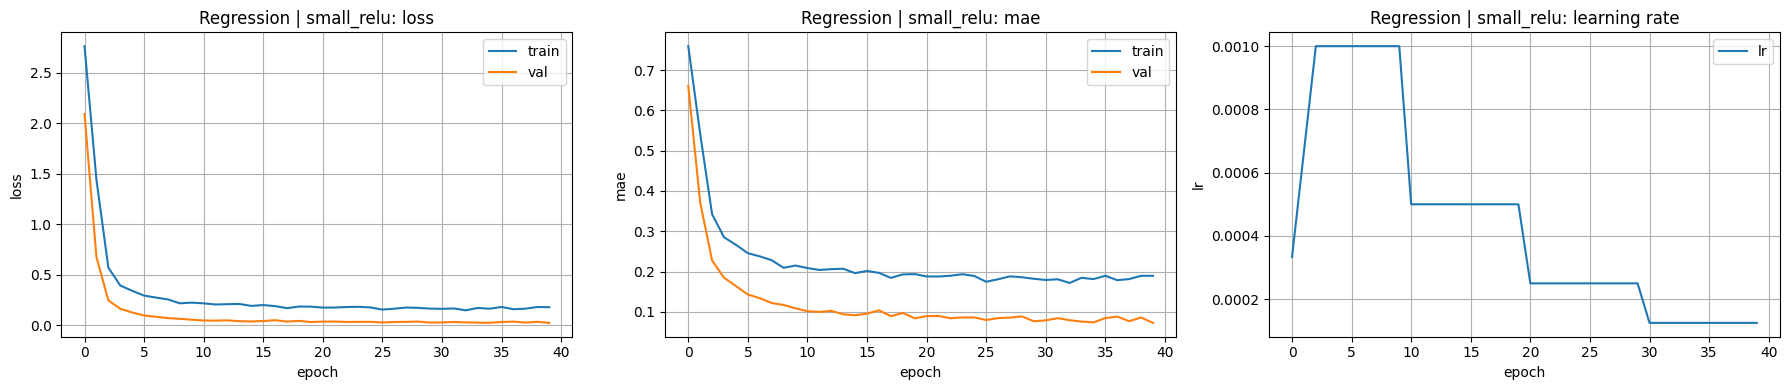

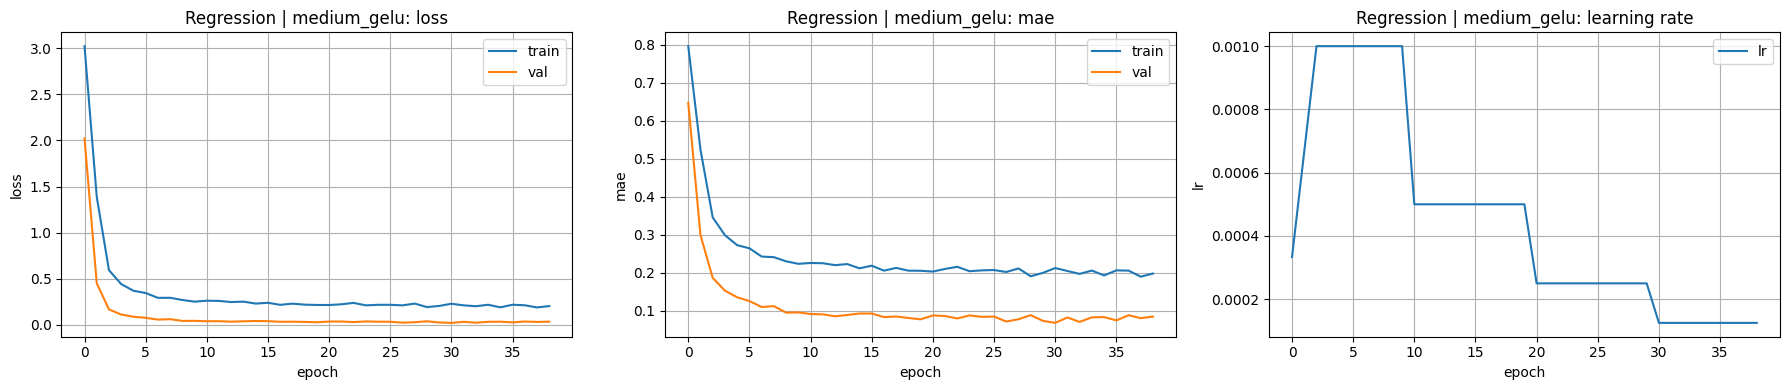

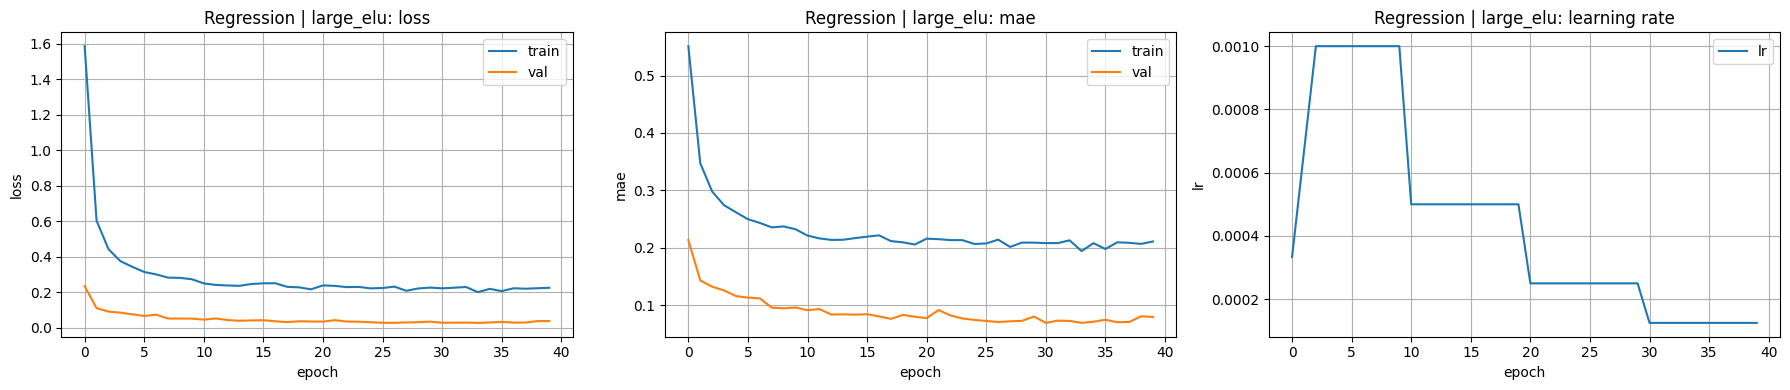

Best regression model by test MAE: small_relu
hidden_dims                                                [64, 32]
activation                                                     ReLU
dropout                                                         0.1
best_epoch                                                       40
best_val_score_scaled                                      0.072466
test_mse_original                                        584.031119
test_rmse_original                                        24.166736
test_mae_original                                         19.012613
best_model_path          artifacts_numpy_models\small_relu_best.npz
Name: small_relu, dtype: object


In [31]:
regression_summary = pd.DataFrame(regression_results).T[
    [
        "hidden_dims",
        "activation",
        "dropout",
        "best_epoch",
        "best_val_score_scaled",
        "test_mse_original",
        "test_rmse_original",
        "test_mae_original",
        "best_model_path"
    ]
].sort_values("test_mae_original")

display(regression_summary)

for exp_name, result in regression_results.items():
    plot_history(
        result["history"],
        title=f"Regression | {exp_name}",
        metric_name=REG_METRIC_NAME
    )

best_regression_name = regression_summary.index[0]
best_regression_model = regression_models[best_regression_name]

print(f"Best regression model by test MAE: {best_regression_name}")
print(regression_summary.loc[best_regression_name])

### Интерпретация результатов регрессии


In [32]:
best_reg_pred_scaled = best_regression_model.forward(X_test_reg_scaled[:10])
best_reg_pred = reg_target_scaler.inverse_transform(best_reg_pred_scaled)

preview_regression = pd.DataFrame({
    "target_1_true": y_test_reg[:10, 0],
    "target_1_pred": best_reg_pred[:10, 0],
    "target_2_true": y_test_reg[:10, 1],
    "target_2_pred": best_reg_pred[:10, 1],
    "target_3_true": y_test_reg[:10, 2],
    "target_3_pred": best_reg_pred[:10, 2],
})

display(preview_regression.round(3))

,target_1_true,target_1_pred,target_2_true,target_2_pred,target_3_true,target_3_pred
0,58.483002,67.895,46.080002,40.268,103.401001,111.624
1,-131.860001,-155.495,-263.123993,-268.683,-132.979996,-161.918
2,-52.612000,-60.508,21.319000,12.450,-1.193000,9.651
3,-467.588989,-483.174,-347.126007,-309.241,6.638000,-18.290
4,-396.506989,-380.894,-399.683990,-416.591,-382.048004,-380.558
5,309.618011,331.915,287.964996,302.848,257.723999,257.417
6,-266.722992,-247.131,-237.533005,-239.403,-182.309998,-174.627
7,-526.685974,-493.623,-254.046997,-263.031,-223.906998,-207.260
8,-68.169998,-83.330,-86.526001,-66.132,-12.688000,-9.640
9,-139.639008,-137.028,-386.412994,-371.727,-43.838001,-59.969


## Мультиклассификация изображений

c MNIST были проблемы, поэтому решил взять что-то похожее

Dataset used: sklearn_digits
Runtime profile: full_dataset
Train: (1257, 1, 8, 8) (1257, 10)
Val:   (270, 1, 8, 8) (270, 10)
Test:  (270, 1, 8, 8) (270, 10)


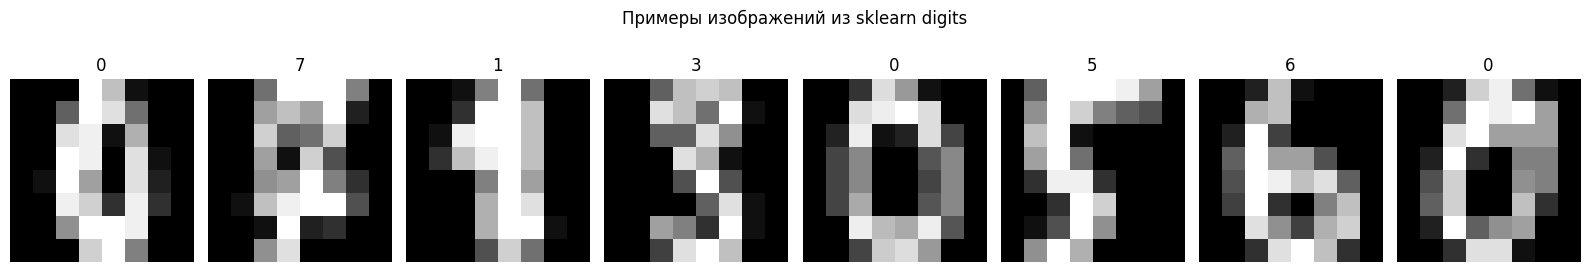

In [44]:
def stratified_subsample(X, y, n_samples, seed=42):
    if n_samples is None or n_samples >= len(X):
        return X, y

    splitter = StratifiedShuffleSplit(n_splits=1, train_size=n_samples, random_state=seed)
    idx, _ = next(splitter.split(X.reshape(len(X), -1), y))
    return X[idx], y[idx]


def load_digits_dataset(seed=42, train_limit=None, val_limit=None, test_limit=None):
    digits = load_digits()

    X_all = (digits.images / 16.0).astype(np.float32)
    y_all = digits.target.astype(int)

    # добавляем размерность канала: (N, 1, H, W)
    X_all = X_all[:, None, :, :]

    X_train, X_temp, y_train, y_temp = train_test_split(
        X_all,
        y_all,
        test_size=0.30,
        random_state=seed,
        stratify=y_all
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=seed,
        stratify=y_temp
    )

    X_train, y_train = stratified_subsample(X_train, y_train, train_limit, seed=seed)
    X_val, y_val = stratified_subsample(X_val, y_val, val_limit, seed=seed)
    X_test, y_test = stratified_subsample(X_test, y_test, test_limit, seed=seed)

    return {
        "dataset_name": "sklearn_digits",
        "runtime_profile": "full_dataset" if all(v is None for v in [train_limit, val_limit, test_limit]) else "reduced_subset",
        "X_train": X_train.astype(np.float32),
        "X_val": X_val.astype(np.float32),
        "X_test": X_test.astype(np.float32),
        "y_train_idx": y_train.astype(int),
        "y_val_idx": y_val.astype(int),
        "y_test_idx": y_test.astype(int),
        "y_train": one_hot(y_train, 10),
        "y_val": one_hot(y_val, 10),
        "y_test": one_hot(y_test, 10),
        "input_shape": X_train.shape[1:],
        "num_classes": 10
    }


vision_data = load_digits_dataset(
    seed=SEED,
    train_limit=None,
    val_limit=None,
    test_limit=None
)

print("Dataset used:", vision_data["dataset_name"])
print("Runtime profile:", vision_data["runtime_profile"])
print("Train:", vision_data["X_train"].shape, vision_data["y_train"].shape)
print("Val:  ", vision_data["X_val"].shape, vision_data["y_val"].shape)
print("Test: ", vision_data["X_test"].shape, vision_data["y_test"].shape)

fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for i, ax in enumerate(axes):
    ax.imshow(vision_data["X_train"][i, 0], cmap="gray")
    ax.set_title(int(vision_data["y_train_idx"][i]))
    ax.axis("off")

plt.suptitle("Примеры изображений из sklearn digits")
plt.tight_layout()
plt.show()

### CNN-архитектура для классификации


In [45]:
def infer_feature_dim(feature_builder, input_shape):
    tmp_model = feature_builder()
    tmp_model.evaluate()

    dummy = np.zeros((2,) + tuple(input_shape), dtype=np.float32)
    out = tmp_model.forward(dummy)

    return out.reshape(out.shape[0], -1).shape[1], out.shape[1:]


def build_cnn_classifier(input_shape=(1, 28, 28), num_classes=10, bn_alpha=0.9):
    def feature_builder():
        model = Sequential()
        model.add(Conv2d(input_shape[0], 4, kernel_size=3, stride=1, padding="same"))
        model.add(BatchNormalization(alpha=bn_alpha))
        model.add(ReLU())
        model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))
        model.add(Dropout(p=0.10))

        model.add(Conv2d(4, 8, kernel_size=3, stride=1, padding="same"))
        model.add(BatchNormalization(alpha=bn_alpha))
        model.add(Gelu())
        model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))
        model.add(Flatten(start_dim=1))
        return model

    flat_dim, feature_shape = infer_feature_dim(feature_builder, input_shape)

    model = feature_builder()
    model.add(Linear(flat_dim, 32))
    model.add(BatchNormalization(alpha=bn_alpha))
    model.add(ReLU())
    model.add(Dropout(p=0.20))
    model.add(Linear(32, num_classes))
    model.add(LogSoftMax())
    return model, flat_dim, feature_shape


cnn_classifier, cnn_flat_dim, cnn_feature_shape = build_cnn_classifier(
    input_shape=vision_data["input_shape"],
    num_classes=vision_data["num_classes"]
)

print(cnn_classifier)
print("Flatten dimension:", cnn_flat_dim)
print("Feature tensor shape before flatten:", cnn_feature_shape)

Conv2d
BatchNormalization
ReLU
MaxPool2d
Dropout
Conv2d
BatchNormalization
Gelu
MaxPool2d
Flatten
Linear 32 -> 32
BatchNormalization
ReLU
Dropout
Linear 32 -> 10
LogSoftMax

Flatten dimension: 32
Feature tensor shape before flatten: (32,)


### Обучение CNN-классификатора

Для классификации я использую:

- **loss**: `ClassNLLCriterion`  
- **metric**: `accuracy`;
- **optimizer**: `AdamW`;
- **warmup**, **scheduler**, **early stopping** и сохранение лучшей модели.

Epoch 001 | train_loss=2.264428 | val_loss=2.163928 | train_accuracy=0.150000 | val_accuracy=0.295635 | lr=0.000500
Epoch 002 | train_loss=1.959171 | val_loss=1.735018 | train_accuracy=0.385764 | val_accuracy=0.668651 | lr=0.001000
Epoch 003 | train_loss=1.685981 | val_loss=1.465191 | train_accuracy=0.536632 | val_accuracy=0.738095 | lr=0.001000
Epoch 004 | train_loss=1.485903 | val_loss=1.281396 | train_accuracy=0.644010 | val_accuracy=0.763393 | lr=0.001000
Epoch 005 | train_loss=1.321101 | val_loss=1.113074 | train_accuracy=0.687847 | val_accuracy=0.802579 | lr=0.001000
Epoch 006 | train_loss=1.162141 | val_loss=0.991920 | train_accuracy=0.747569 | val_accuracy=0.830357 | lr=0.001000
Epoch 007 | train_loss=1.077043 | val_loss=0.928518 | train_accuracy=0.770312 | val_accuracy=0.840774 | lr=0.000500
Epoch 008 | train_loss=1.006226 | val_loss=0.850608 | train_accuracy=0.790104 | val_accuracy=0.837302 | lr=0.000500
Epoch 009 | train_loss=0.961968 | val_loss=0.818361 | train_accuracy=0.7

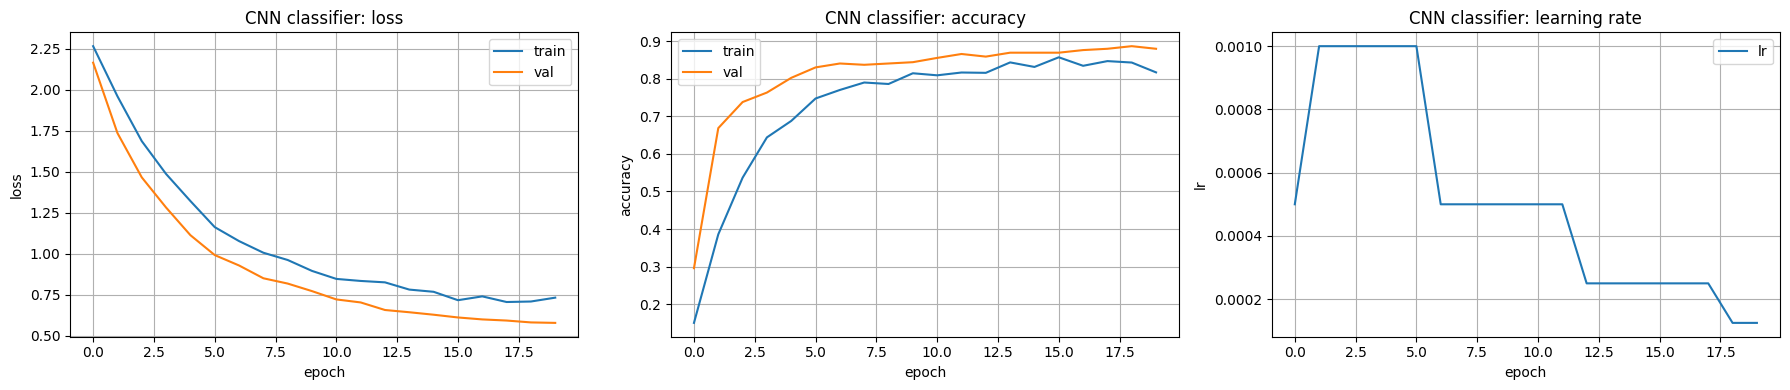

Best epoch: 19
Test loss:  0.510740
Test acc:   0.904266
Best model saved to: artifacts_numpy_models\cnn_classifier_best.npz


In [46]:
CLS_OPTIMIZER_NAME = "adamw"
CLS_LOSS_NAME = "nll"
CLS_METRIC_NAME = "accuracy"

if vision_data["dataset_name"] == "MNIST":
    cls_epochs = 8
    cls_patience = 4
else:
    cls_epochs = 20
    cls_patience = 6

criterion_cls = make_criterion(task="classification", loss_name=CLS_LOSS_NAME)
metric_fn_cls = make_metric(task="classification", metric_name=CLS_METRIC_NAME)

optimizer_cls = make_optimizer(
    name=CLS_OPTIMIZER_NAME,
    model=cnn_classifier,
    lr=1e-3,
    weight_decay=1e-4
)

cnn_best_path = os.path.join(ARTIFACT_DIR, "cnn_classifier_best.npz")

cnn_fit_result = fit_model(
    model=cnn_classifier,
    criterion=criterion_cls,
    optimizer=optimizer_cls,
    X_train=vision_data["X_train"],
    y_train=vision_data["y_train"],
    X_val=vision_data["X_val"],
    y_val=vision_data["y_val"],
    n_epochs=cls_epochs,
    batch_size=32,
    metric_fn=metric_fn_cls,
    metric_name=CLS_METRIC_NAME,
    maximize_metric=True,
    early_stopping_patience=cls_patience,
    scheduler_step=max(2, cls_epochs // 3),
    scheduler_gamma=0.5,
    warmup_epochs=min(2, cls_epochs),
    best_model_path=cnn_best_path,
    verbose=True
)

plot_history(cnn_fit_result["history"], title="CNN classifier", metric_name=CLS_METRIC_NAME)

test_loss_cls, test_acc_cls = evaluate_epoch(
    model=cnn_classifier,
    criterion=criterion_cls,
    X_val=vision_data["X_test"],
    y_val=vision_data["y_test"],
    batch_size=32,
    metric_fn=metric_fn_cls
)

print(f"Best epoch: {cnn_fit_result['best_epoch']}")
print(f"Test loss:  {test_loss_cls:.6f}")
print(f"Test acc:   {test_acc_cls:.6f}")
print(f"Best model saved to: {cnn_best_path}")

### Проверка качества на тесте: confusion matrix и примеры предсказаний


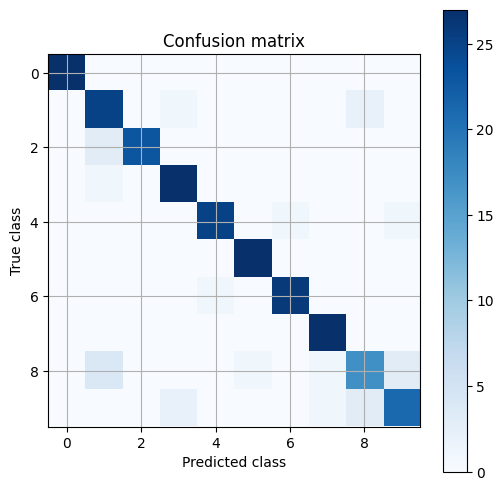

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        27
           1     0.7576    0.8929    0.8197        28
           2     1.0000    0.8846    0.9388        26
           3     0.9000    0.9643    0.9310        28
           4     0.9615    0.9259    0.9434        27
           5     0.9643    1.0000    0.9818        27
           6     0.9630    0.9630    0.9630        27
           7     0.9310    1.0000    0.9643        27
           8     0.7727    0.6538    0.7083        26
           9     0.8400    0.7778    0.8077        27

    accuracy                         0.9074       270
   macro avg     0.9090    0.9062    0.9058       270
weighted avg     0.9086    0.9074    0.9062       270



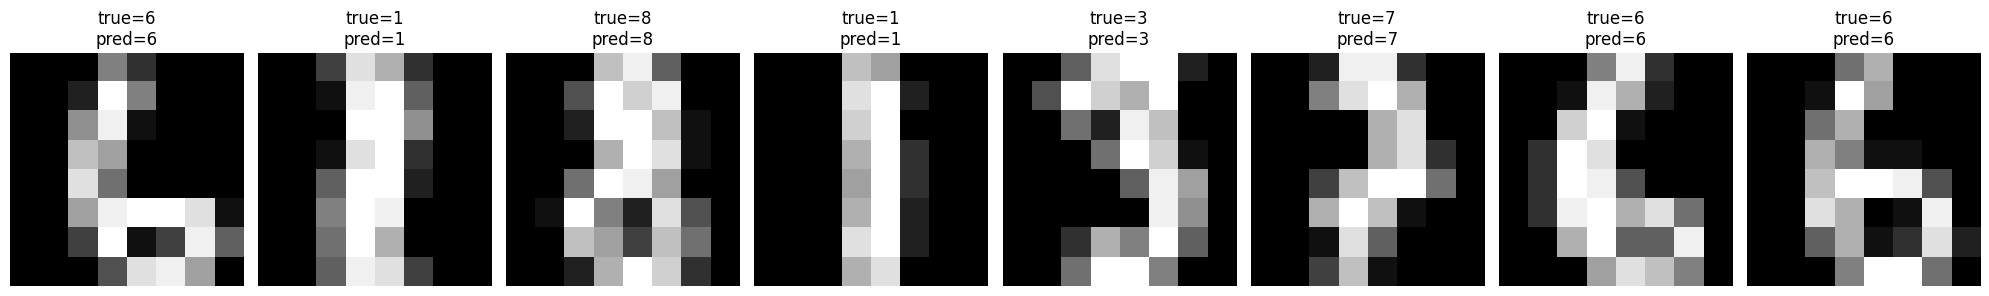

In [47]:
test_log_probs = cnn_classifier.forward(vision_data["X_test"])
test_pred_idx = np.argmax(test_log_probs, axis=1)

cm = confusion_matrix(vision_data["y_test_idx"], test_pred_idx)

plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar()
plt.show()

print(classification_report(vision_data["y_test_idx"], test_pred_idx, digits=4))

n_show = min(8, len(vision_data["X_test"]))
fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 3))

for i, ax in enumerate(axes):
    ax.imshow(vision_data["X_test"][i, 0], cmap="gray")
    ax.set_title(
        f"true={vision_data['y_test_idx'][i]}\npred={test_pred_idx[i]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

##  Автоэнкодер



In [48]:
def build_conv_autoencoder(input_shape=(1, 28, 28), latent_dim=16, bn_alpha=0.9):
    def encoder_feature_builder():
        model = Sequential()
        model.add(Conv2d(input_shape[0], 4, kernel_size=3, stride=1, padding="same"))
        model.add(BatchNormalization(alpha=bn_alpha))
        model.add(ReLU())
        model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))
        model.add(Dropout(p=0.10))

        model.add(Conv2d(4, 8, kernel_size=3, stride=1, padding="same"))
        model.add(BatchNormalization(alpha=bn_alpha))
        model.add(Gelu())
        model.add(MaxPool2d(kernel_size=2, stride=2, padding=0))
        model.add(Flatten(start_dim=1))
        return model

    flat_dim, feature_shape = infer_feature_dim(encoder_feature_builder, input_shape)

    model = encoder_feature_builder()
    model.add(Linear(flat_dim, 64))
    model.add(BatchNormalization(alpha=bn_alpha))
    model.add(ReLU())
    model.add(Dropout(p=0.20))

    model.add(Linear(64, latent_dim))
    model.add(BatchNormalization(alpha=bn_alpha))
    model.add(Gelu())

    model.add(Linear(latent_dim, 64))
    model.add(BatchNormalization(alpha=bn_alpha))
    model.add(ReLU())
    model.add(Dropout(p=0.10))

    model.add(Linear(64, 128))
    model.add(BatchNormalization(alpha=bn_alpha))
    model.add(ReLU())

    model.add(Linear(128, int(np.prod(input_shape))))
    return model, flat_dim, feature_shape


autoencoder, ae_flat_dim, ae_feature_shape = build_conv_autoencoder(
    input_shape=vision_data["input_shape"],
    latent_dim=16
)

print(autoencoder)
print("Flatten dimension:", ae_flat_dim)
print("Feature tensor shape before flatten:", ae_feature_shape)

Conv2d
BatchNormalization
ReLU
MaxPool2d
Dropout
Conv2d
BatchNormalization
Gelu
MaxPool2d
Flatten
Linear 32 -> 64
BatchNormalization
ReLU
Dropout
Linear 64 -> 16
BatchNormalization
Gelu
Linear 16 -> 64
BatchNormalization
ReLU
Dropout
Linear 64 -> 128
BatchNormalization
ReLU
Linear 128 -> 64

Flatten dimension: 32
Feature tensor shape before flatten: (32,)


### Обучение автоэнкодера

В автоэнкодере **вход и таргет совпадают**, поэтому:

- `X` — это изображения;
- `y` — это те же изображения, только в **flatten**-виде, потому что декодер возвращает вектор длины `H × W`.

В качестве дополнительной метрики беру **MAE**, чтобы следить не только за квадратичной, но и за абсолютной ошибкой реконструкции.

Epoch 001 | train_loss=14.637773 | val_loss=6.894438 | train_mae=0.359619 | val_mae=0.247196 | lr=0.000500
Epoch 002 | train_loss=6.331273 | val_loss=4.261372 | train_mae=0.240469 | val_mae=0.193035 | lr=0.001000
Epoch 003 | train_loss=4.829090 | val_loss=3.613068 | train_mae=0.205574 | val_mae=0.173732 | lr=0.001000
Epoch 004 | train_loss=4.101271 | val_loss=3.152124 | train_mae=0.186477 | val_mae=0.158715 | lr=0.001000
Epoch 005 | train_loss=3.730684 | val_loss=2.925365 | train_mae=0.174745 | val_mae=0.150766 | lr=0.001000
Epoch 006 | train_loss=3.519017 | val_loss=2.752193 | train_mae=0.167760 | val_mae=0.143879 | lr=0.001000
Epoch 007 | train_loss=3.294588 | val_loss=2.684583 | train_mae=0.160458 | val_mae=0.142193 | lr=0.001000
Epoch 008 | train_loss=3.151273 | val_loss=2.562885 | train_mae=0.156449 | val_mae=0.137219 | lr=0.001000
Epoch 009 | train_loss=3.056787 | val_loss=2.454061 | train_mae=0.152655 | val_mae=0.133650 | lr=0.000500
Epoch 010 | train_loss=3.008873 | val_loss=2.

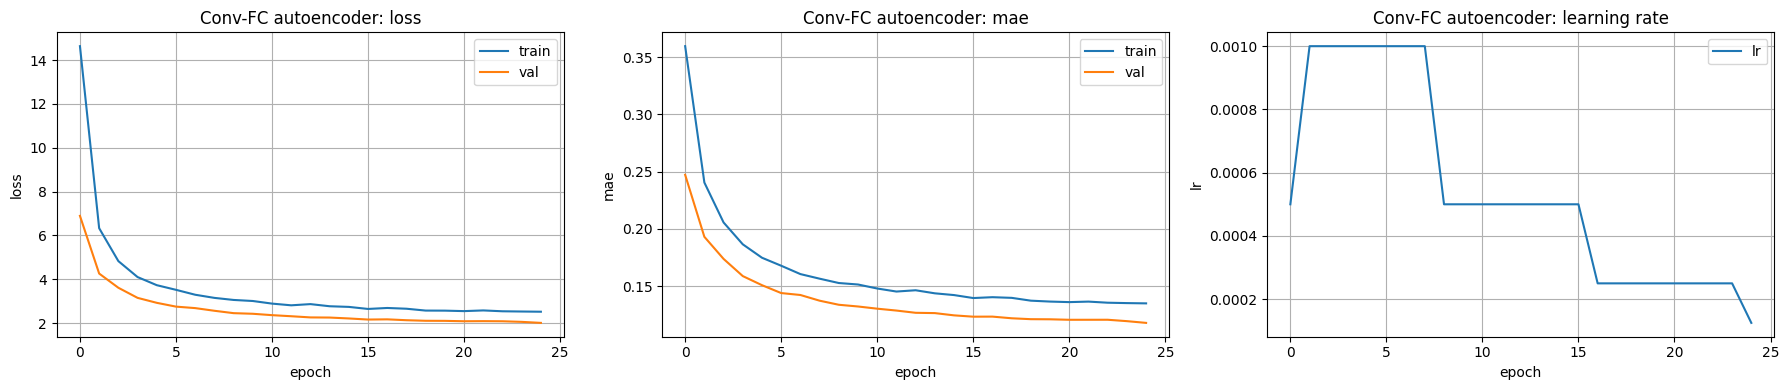

Best epoch: 25
Test MSE:   1.851818
Test MAE:   0.113111
Best model saved to: artifacts_numpy_models\conv_autoencoder_best.npz


In [49]:
AE_OPTIMIZER_NAME = "adamw"
AE_LOSS_NAME = "mse"
AE_METRIC_NAME = "mae"

if vision_data["dataset_name"] == "MNIST":
    ae_epochs = 10
    ae_patience = 4
else:
    ae_epochs = 25
    ae_patience = 6

X_train_ae_target = vision_data["X_train"].reshape(len(vision_data["X_train"]), -1)
X_val_ae_target = vision_data["X_val"].reshape(len(vision_data["X_val"]), -1)
X_test_ae_target = vision_data["X_test"].reshape(len(vision_data["X_test"]), -1)

criterion_ae = make_criterion(task="autoencoder", loss_name=AE_LOSS_NAME)
metric_fn_ae = make_metric(task="autoencoder", metric_name=AE_METRIC_NAME)

optimizer_ae = make_optimizer(
    name=AE_OPTIMIZER_NAME,
    model=autoencoder,
    lr=1e-3,
    weight_decay=1e-4
)

ae_best_path = os.path.join(ARTIFACT_DIR, "conv_autoencoder_best.npz")

ae_fit_result = fit_model(
    model=autoencoder,
    criterion=criterion_ae,
    optimizer=optimizer_ae,
    X_train=vision_data["X_train"],
    y_train=X_train_ae_target,
    X_val=vision_data["X_val"],
    y_val=X_val_ae_target,
    n_epochs=ae_epochs,
    batch_size=32,
    metric_fn=metric_fn_ae,
    metric_name=AE_METRIC_NAME,
    maximize_metric=False,
    early_stopping_patience=ae_patience,
    scheduler_step=max(2, ae_epochs // 3),
    scheduler_gamma=0.5,
    warmup_epochs=min(2, ae_epochs),
    best_model_path=ae_best_path,
    verbose=True
)

plot_history(ae_fit_result["history"], title="Conv-FC autoencoder", metric_name=AE_METRIC_NAME)

test_loss_ae, test_mae_ae = evaluate_epoch(
    model=autoencoder,
    criterion=criterion_ae,
    X_val=vision_data["X_test"],
    y_val=X_test_ae_target,
    batch_size=32,
    metric_fn=metric_fn_ae
)

print(f"Best epoch: {ae_fit_result['best_epoch']}")
print(f"Test MSE:   {test_loss_ae:.6f}")
print(f"Test MAE:   {test_mae_ae:.6f}")
print(f"Best model saved to: {ae_best_path}")

### Качество реконструкции: визуализация

Здесь я показываю пары:

- **original**
- **reconstruction**


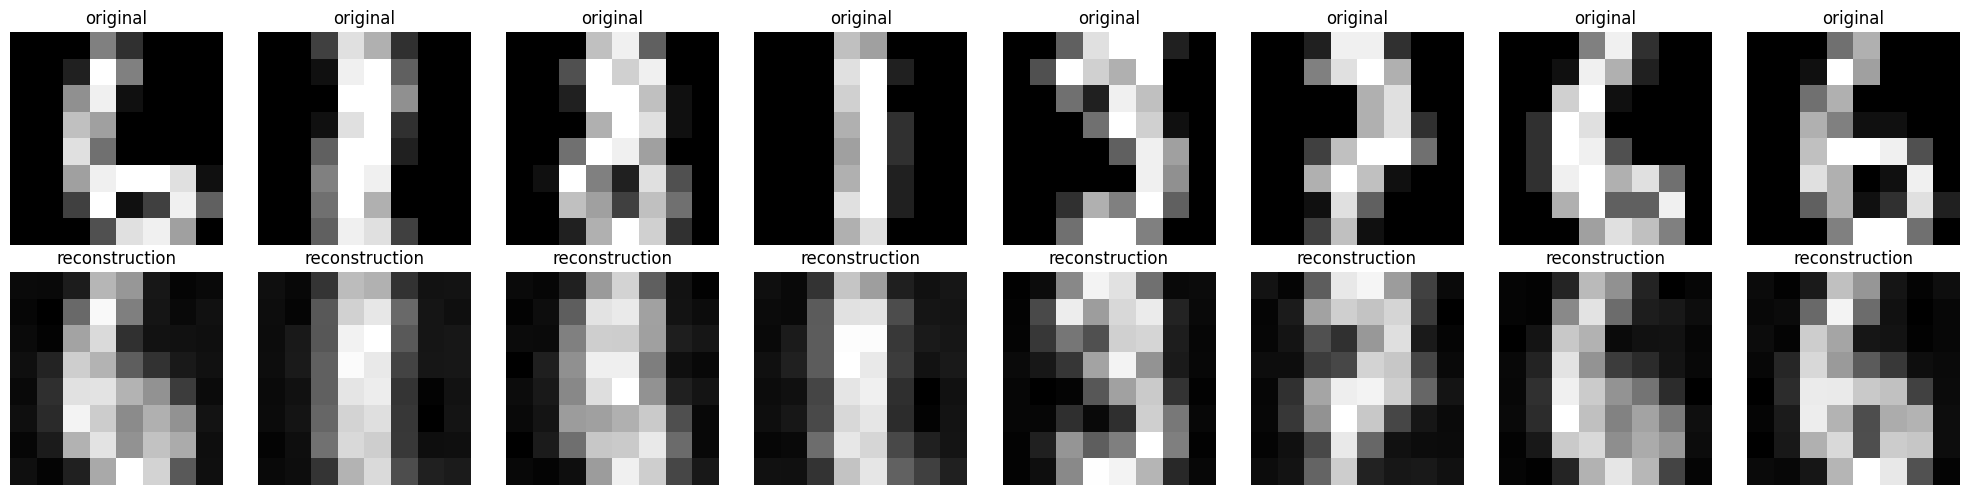

Latent dimension: 16
Approximate compression ratio: 4.00x


In [50]:
ae_test_recon_flat = autoencoder.forward(vision_data["X_test"])
H, W = vision_data["input_shape"][1], vision_data["input_shape"][2]

ae_test_recon = ae_test_recon_flat.reshape(-1, H, W)
ae_test_true = vision_data["X_test"][:, 0]

n_show = min(8, len(ae_test_true))

fig, axes = plt.subplots(2, n_show, figsize=(2.5 * n_show, 5))

for i in range(n_show):
    axes[0, i].imshow(ae_test_true[i], cmap="gray")
    axes[0, i].set_title("original")
    axes[0, i].axis("off")

    axes[1, i].imshow(ae_test_recon[i], cmap="gray")
    axes[1, i].set_title("reconstruction")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

latent_dim = 16
compression_ratio = int(np.prod(vision_data["input_shape"])) / latent_dim
print(f"Latent dimension: {latent_dim}")
print(f"Approximate compression ratio: {compression_ratio:.2f}x")